<a href="https://colab.research.google.com/github/iconrealestate77/diabetes-risk-prediction-mlp/blob/main/diabetes_prediction_mlp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Multi Layer Perceptron for Diabetes Risk Prediction

Welcome to your Deep Learning project! In this notebook, you’ll take on the role of a data scientist building a neural network that predicts diabetes risk, helping healthcare providers prioritize patients for diagnostic testing.

### What you'll build

By completing this notebook, you will _(demonstrate ability to)_:

- Design MLP architectures with appropriate depth, width, and activations
- Preprocess data with proper splitting, normalization, and batching
- Implement training loops with forward/backward passes and optimization
- Apply evaluation metrics suited for specialized applications
- Diagnose overfitting/underfitting using loss curves
- Improve models systematically through hyperparameter tuning and regularization
- Interpret performance in context with actionable recommendations

**Dataset**: [CDC Diabetes Health Indicators](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) (balanced subset of 50,000 patients, 21 features)  
**Estimated time**: 5-6 hours  

> *Have more questions about the project?* Review the [README.md](../README.md) for full project context, setup instructions, and deliverables.

### Ready to get started?

This notebook is divided into 8 sections:

```Setup → Data Loading → Data Preprocessing → Model Design → Model Training → Model Evaluation → Model Improvements → Conclusion```

Follow them in sequence to complete your project!

---
## Step 0: Set up the environment

Let's begin by importing the necessary libraries and setting up our environment for reproducibility.

In [ ]:
# Standard library imports
import numpy as np
import pandas as pd
import numbers
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Optional

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully!
PyTorch version: 2.11.0+cu128


In [ ]:
# Set random seeds for reproducibility
# This ensures that your results are consistent across runs
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


> **Why reproducibility matters**: Setting random seeds ensures that your results are consistent across different runs. This is critical for debugging and comparing different model configurations.
> <br>In production systems, reproducibility helps with model versioning and validation.

In [ ]:
# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Set cuDNN to deterministic mode for reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Using device: cuda
GPU: Tesla T4


> **Moving execution to device**: Transferring your model and tensors to the GPU can drastically improve performance.  
> <br>Use `.to(device)` for models and tensors to ensure everything runs on the same hardware.  
> <br>*Example:*  
> ```model = model.to(device)```   
> ```inputs = inputs.to(device)```  
> <br>**Note**: Mixing CPU and GPU tensors in operations will raise errors.

---
## Step 1: Load and explore the dataset

Understanding your data is the first critical step in any deep learning project. In this step, you will load the dataset and perform exploratory data analysis to understand your dataset.

The CDC diabetes dataset is provided as a CSV file in the [`data/`](../data/) directory. You'll use [pandas](https://pandas.pydata.org/) to load it into a DataFrame for analysis.

### 1.1 Load the dataset

The dataset contains health indicators from the CDC's Behavioral Risk Factor Surveillance System. Each row represents a patient with 21 health-related features and a binary diabetes diagnosis.

In [ ]:
!git clone https://github.com/iconrealestate77/diabetes-risk-prediction-mlp.git

df = pd.read_csv('/content/diabetes-risk-prediction-mlp/starter-kit/data/diabetes_data.csv')

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


fatal: destination path 'diabetes-risk-prediction-mlp' already exists and is not an empty directory.
Dataset loaded successfully!
Dataset shape: (50000, 22)

First few rows:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,27,1,0,0,1,0,1,...,0,2,0,0,0,1,12,6,8,1
1,0,0,1,30,0,0,0,1,1,1,...,0,1,0,0,0,1,8,5,5,0
2,1,0,1,33,0,0,0,1,1,1,...,0,3,0,0,0,0,7,5,6,0
3,1,1,1,25,0,0,0,1,1,1,...,0,1,0,0,0,1,9,6,4,0
4,1,1,1,29,1,0,1,0,0,1,...,0,5,3,10,1,0,9,4,2,1


In [ ]:
print("Shape:", df.shape)
print("\nColumn names and data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
df.head()


Shape: (50000, 22)

Column names and data types:
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

Missing values per column:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies        

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,27,1,0,0,1,0,1,...,0,2,0,0,0,1,12,6,8,1
1,0,0,1,30,0,0,0,1,1,1,...,0,1,0,0,0,1,8,5,5,0
2,1,0,1,33,0,0,0,1,1,1,...,0,3,0,0,0,0,7,5,6,0
3,1,1,1,25,0,0,0,1,1,1,...,0,1,0,0,0,1,9,6,4,0
4,1,1,1,29,1,0,1,0,0,1,...,0,5,3,10,1,0,9,4,2,1


### 1.2 Understanding the features

The dataset contains 21 health and lifestyle indicators. Let's examine what each feature represents and its clinical significance:

| Feature | Description | Type | Clinical Significance |
|---------|-------------|------|----------------------|
| **Diabetes_binary** | Diabetes diagnosis | Binary (0/1) | **Target variable** |
| HighBP | High blood pressure diagnosis | Binary | Strong risk factor |
| HighChol | High cholesterol diagnosis | Binary | Cardiovascular risk |
| CholCheck | Cholesterol check in past 5 years | Binary | Preventive care indicator |
| BMI | Body Mass Index | Continuous | Key obesity indicator |
| Smoker | Smoking history | Binary | Lifestyle risk factor |
| Stroke | History of stroke | Binary | Cardiovascular complication |
| HeartDiseaseorAttack | Coronary heart disease or MI | Binary | Cardiovascular complication |
| PhysActivity | Physical activity in past 30 days | Binary | Protective factor |
| Fruits | Fruit consumption (1+ per day) | Binary | Dietary indicator |
| Veggies | Vegetable consumption (1+ per day) | Binary | Dietary indicator |
| HvyAlcoholConsump | Heavy alcohol consumption | Binary | Lifestyle risk factor |
| AnyHealthcare | Any healthcare coverage | Binary | Access to care |
| NoDocbcCost | Could not see doctor due to cost | Binary | Healthcare barrier |
| GenHlth | General health (1-5 scale) | Ordinal | Self-reported health status |
| MentHlth | Mental health (days not good in past 30) | Continuous | Mental health indicator |
| PhysHlth | Physical health (days not good in past 30) | Continuous | Physical health indicator |
| DiffWalk | Difficulty walking or climbing stairs | Binary | Mobility indicator |
| Sex | Biological sex | Binary | Demographic factor |
| Age | Age category (1-13) | Ordinal | Strong demographic predictor |
| Education | Education level (1-6) | Ordinal | Socioeconomic indicator |
| Income | Income level (1-8) | Ordinal | Socioeconomic indicator |

For a complete overview of the dataset, refer to the [`data/data_dictionary.md`](data/data_dictionary.md) file.

> **Feature dictionaries in the real-world**: In practice, you'll often create these yourself by interviewing domain experts. Always document: feature meaning, type, measurement method, and known limitations.
> <br> Think of the feature dictionary as your model's "instruction manual"; without it, even brilliant ML work becomes unusable in production.


### 1.3 Perform exploratory data analysis (EDA)

Understanding your data involves checking for missing values, reviewing feature distributions, understanding target variable distribution, and identifying patterns that will inform your modeling decisions.

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")


Missing values per column:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

Total missing values: 0


> **Handling missing values** Even though this dataset has no missing values, it's crucial to check for them in any data workflow since they can disrupt model training, bias results, or break computations. Common strategies to handle missing values include:
>   - *Removal:* Drop rows or columns if the proportion of missing data is small.  
>   - *Imputation:* Fill with mean, median, mode, or domain-specific defaults.  
>   - *Model-based methods:* Predict missing values using other features.  
> Always make sure to also analyze *why* data is missing: it can reveal data collection issues or hidden patterns!  
>
> *Reference:* [ Working with missing data in Pandas](https://pandas.pydata.org/docs/user_guide/missing_data.html)


Target Variable Distribution:
No Diabetes (0): 25,000 (50.00%)
Diabetes (1): 25,000 (50.00%)


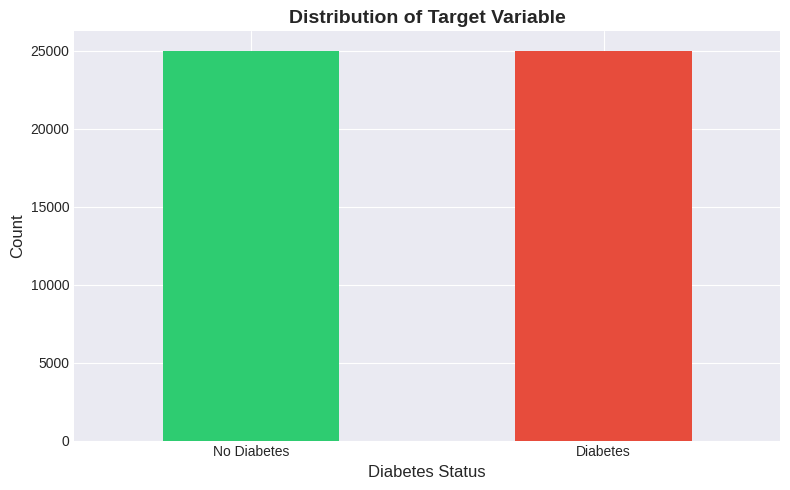

In [ ]:
target_distribution = df['Diabetes_binary'].value_counts()
target_percentage = df['Diabetes_binary'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"No Diabetes (0): {target_distribution[0]:,} ({target_percentage[0]:.2f}%)")
print(f"Diabetes (1): {target_distribution[1]:,} ({target_percentage[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
target_distribution.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xlabel('Diabetes Status', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Target Variable', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
plt.tight_layout()
plt.show()


> **Understanding the balanced dataset:** You have noticed this dataset has a 50-50 split between diabetic and non-diabetic patients. The original CDC data actually has ~14% diabetes prevalence, reflecting real population statistics.
>
> Why did we balance it?
> - *Simplifies learning:* Lets you focus on neural network fundamentals without juggling class imbalance complexity
> - *Valid strategy:* Downsampling the majority class is common in production when you have enough minority samples (we have 7,000+ diabetic cases!)
> - *Practical benefits:* Simpler code, faster training, often performs just as well
>
> Alternatives to deal with class imbalance involve upsampling and/or cost-sensitive learning.
>
> *Production note:* You'd typically train on balanced data but evaluate on the real distribution. Here we use balanced for both to keep things simple, but remember to test on realistic proportions before deployment!

In [ ]:
df.describe()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.561180,0.52728,0.975780,29.869340,0.47422,0.06210,0.150300,0.703720,0.612600,0.786160,...,0.09464,2.838020,3.705240,5.801720,0.252460,0.457420,8.585920,4.922560,5.703160,0.500000
std,0.496248,0.49926,0.153733,7.183087,0.49934,0.24134,0.357369,0.456621,0.487161,0.410019,...,0.29272,1.113125,8.097735,10.058292,0.434428,0.498189,2.847873,1.030429,2.171308,0.500005
min,0.000000,0.00000,0.000000,12.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.00000,1.000000,25.000000,0.00000,0.00000,0.000000,0.000000,0.000000,1.000000,...,0.00000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000,0.000000
50%,1.000000,1.00000,1.000000,29.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,...,0.00000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000,0.500000
75%,1.000000,1.00000,1.000000,33.000000,1.00000,0.00000,0.000000,1.000000,1.000000,1.000000,...,0.00000,4.000000,2.000000,5.000000,1.000000,1.000000,11.000000,6.000000,8.000000,1.000000
max,1.000000,1.00000,1.000000,98.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.00000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


> **Understanding statistical summaries** Statistical summaries provide a quick snapshot of your dataset’s structure and variability.  
>
> - *Central tendency:* Metrics like mean and median reveal typical values but can be distorted by skewed data or outliers.  
> - *Spread:* Standard deviation and quartiles highlight how dispersed the data is, where wide spreads may indicate inconsistent scales or high variability.  
> - *Range and extremes:* Min/max values help spot potential data entry errors or outliers needing review.  
> - *Feature type awareness:*  
>   - Continuous features benefit from scale checks and normalization.  
>   - Ordinal or categorical features should be interpreted by the distribution of categories, not numeric statistics.  
>
> *Why this matters:* Understanding the shape, spread, and nature of your data guides preprocessing decisions like scaling, encoding, and handling outliers for reliable modeling.


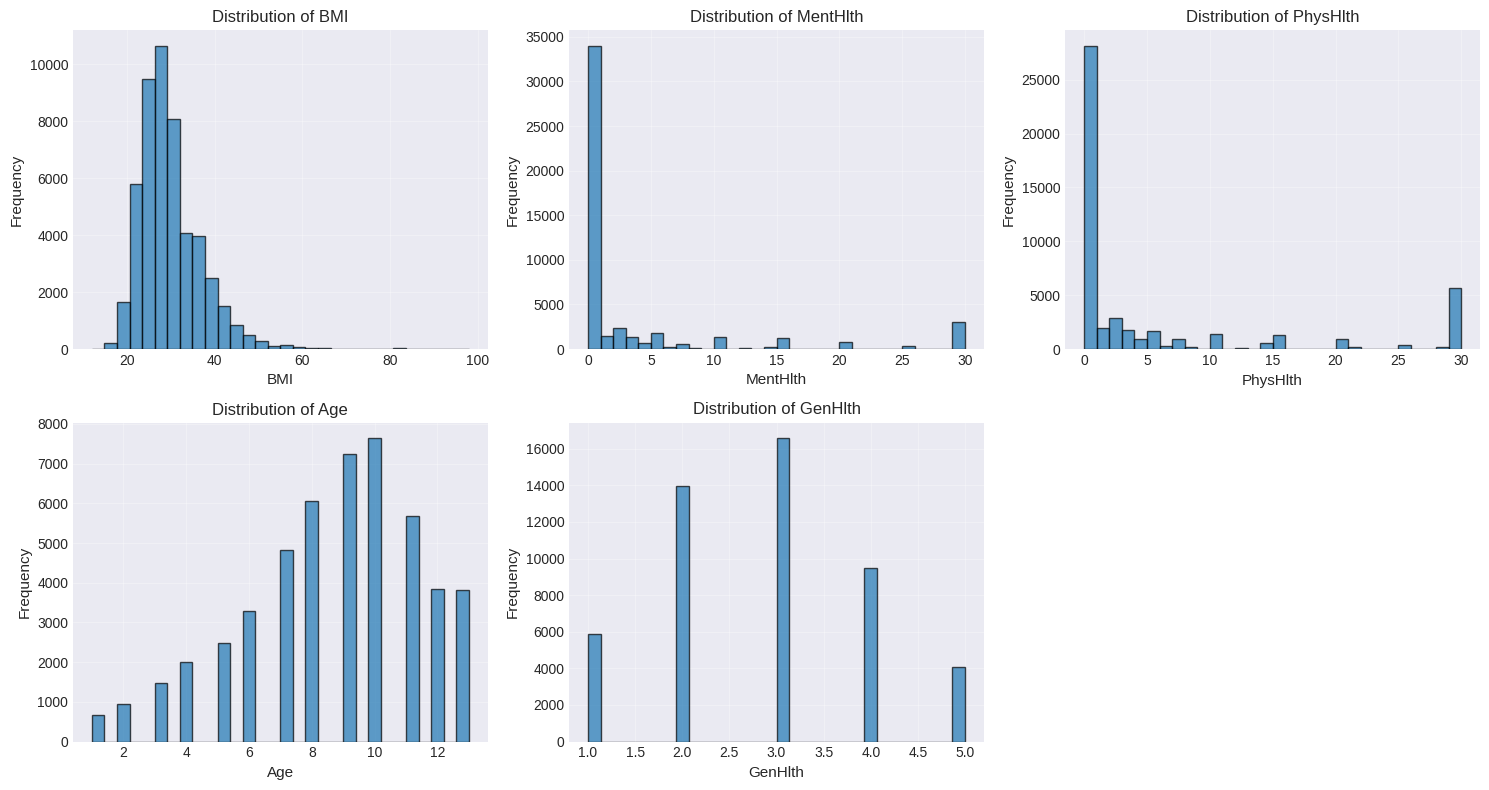

In [ ]:
# Visualize distributions of key continuous features
continuous_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'GenHlth']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(continuous_features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

> **Interpreting the distribution plots** These histograms reveal how each continuous feature is distributed:  
> - *Shape:* Skewed or symmetric distributions indicate how values are spread.  
> - *Spread:* Wide distributions suggest high variability; scaling will be needed.  
> - *Peaks:* Multiple peaks can hint at subgroups or hidden patterns in the data.  
> - *Outliers:* Extreme values can distort model learning; worth investigating.  
> - *Continuity:* Features with few distinct values might behave more like categories.

Feature Correlations with Diabetes:
Diabetes_binary         1.000000
GenHlth                 0.406625
HighBP                  0.384610
HighChol                0.283302
BMI                     0.282141
Age                     0.280998
DiffWalk                0.270842
PhysHlth                0.215880
HeartDiseaseorAttack    0.208582
Stroke                  0.127208
CholCheck               0.113575
MentHlth                0.096566
Smoker                  0.085354
Sex                     0.047573
NoDocbcCost             0.037306
AnyHealthcare           0.027282
Fruits                 -0.057641
Veggies                -0.069071
HvyAlcoholConsump      -0.099634
PhysActivity           -0.160485
Education              -0.169717
Income                 -0.226207
Name: Diabetes_binary, dtype: float64


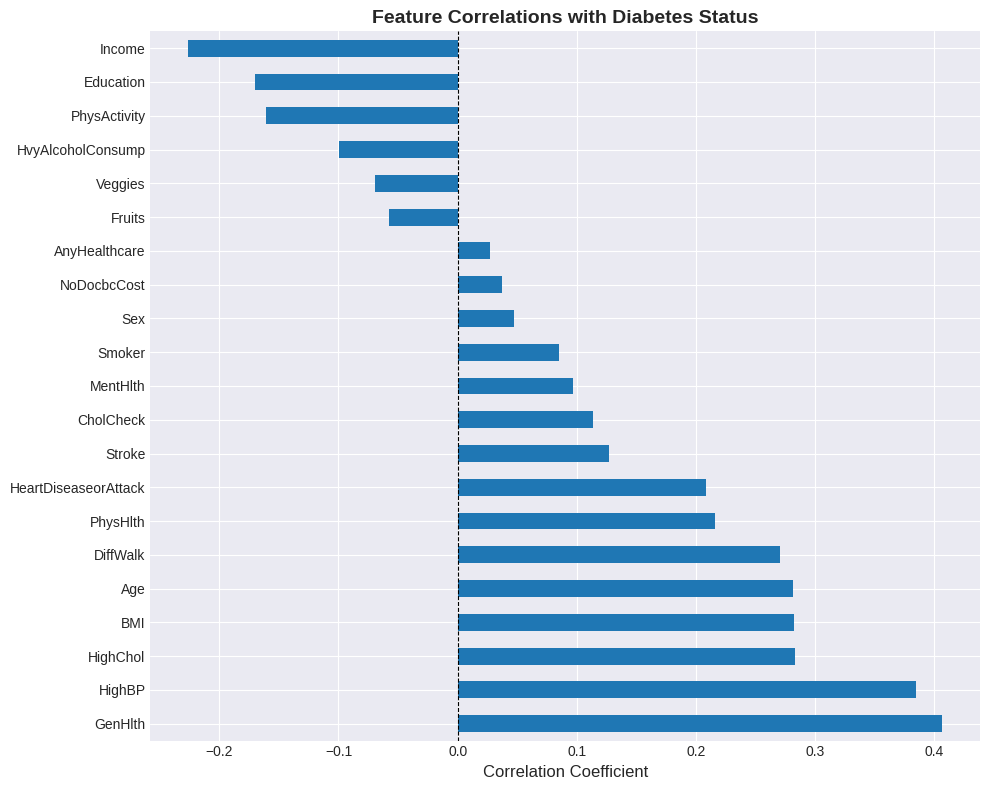

In [ ]:
correlations = df.corr()['Diabetes_binary'].sort_values(ascending=False)

print("Feature Correlations with Diabetes:")
print(correlations)

fig, ax = plt.subplots(figsize=(10, 8))
correlations[1:].plot(kind='barh', ax=ax)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlations with Diabetes Status', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


> **Understanding correlations** Correlations show how features move together, not cause and effect.  
> - *Positive* → variables increase together; *Negative* → one rises as the other falls.  
> - Strong values (±1) imply tighter linear links; near 0 means weak or no linear relation.  
> - Watch for *multicollinearity* and remember that *nonlinear patterns* won’t appear here.  
>  
> *IMPORTANT*: Use correlations to spot patterns, not to draw conclusions.

### 1.4 Collect key observations from EDA

Document 5-10 key observations from the exploratory data analysis. Consider: class balance, feature ranges, correlations, missing data, and data quality.

*TODO 6: Write your observations as bullet points here:*

TODO 6 — EDA observations

The dataset is a perfectly balanced 50/50 split: 25,000 patients with no diabetes and 25,000 with diabetes, out of 50,000 total patients. This differs from the real-world CDC prevalence of ~14%, so metrics here won’t directly reflect real-world class distribution.
No missing values were found in any of the 22 columns, simplifying preprocessing (no imputation needed).
General health rating (GenHlth) is the strongest positive correlate with diabetes at 0.4066, followed by HighBP (0.3846), HighChol (0.2833), BMI (0.2821), and Age (0.2810) — all clinically consistent with known diabetes risk factors.
Difficulty walking (DiffWalk) correlates moderately (0.2708), likely reflecting reduced mobility as a downstream complication or comorbidity of diabetes.
Income and Education are the strongest negative correlates (-0.2262 and -0.1697 respectively), suggesting socioeconomic factors play a meaningful protective/risk role — likely tied to healthcare access and lifestyle factors rather than being direct medical predictors.
Physical activity (PhysActivity) is also negatively correlated (-0.1605), consistent with exercise being protective against diabetes risk.
Lifestyle/dietary indicators like Fruits (-0.0576) and Veggies (-0.0691) show only weak correlations, suggesting diet alone (as captured by this binary yes/no feature) isn’t a strong standalone predictor in this dataset.
Sex (0.0476), Smoker (0.0854), and AnyHealthcare (0.0273) show minimal correlation with diabetes status, indicating these features alone carry limited predictive signal.
Given the spread of correlation strengths (from -0.23 to +0.41) and the mix of binary/ordinal/continuous feature types, feature scaling (normalization) will be essential before training, since raw feature ranges vary significantly (e.g., BMI vs. binary flags).


<details open>
  <summary><h4>Checkpoint – Understanding the dataset</h4></summary>
  
  Before proceeding to preprocessing, ensure you understand:

  - [ ] The target variable distribution and its implications for evaluation
  - [ ] Which features show strong correlations with diabetes
  - [ ] The need for feature scaling due to different value ranges
  - [ ] The absence of missing values (simplifies preprocessing)

</details>

---
## Step 2: Preprocess the dataset

Proper data preprocessing is essential for neural network training. Raw data often needs to be split, normalized, and batched before it can be used effectively. This section transforms your dataset into a format optimized for PyTorch models.

### 2.1 Separate features and target

Machine learning models require splitting your data into input features (X) and target labels (y). The features are what the model uses to make predictions, while the target is what you're trying to predict.

In [ ]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")


Features shape: (50000, 21)
Target shape: (50000,)

Feature columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


### 2.2 Create train/validation/test splits

Following best practices, you'll split the data into three sets:

- Training set (60%): Used to train the model (learn patterns, update weights)
- Validation set (20%): Used during development to tune hyperparameters and monitor overfitting
- Test set (20%): Final evaluation on completely unseen data (simulates real-world deployment)

This is a best practice because separating validation from testing ensures that model tuning doesn’t “leak” information from your final evaluation, leading to more trustworthy results.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_SEED)


In [ ]:
# Verify split sizes and class distributions
print("Split Sizes:")
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\nClass Distribution:")
print(f"Training - Diabetes prevalence: {y_train.mean()*100:.2f}%")
print(f"Validation - Diabetes prevalence: {y_val.mean()*100:.2f}%")
print(f"Test - Diabetes prevalence: {y_test.mean()*100:.2f}%")

Split Sizes:
Training set: 30,000 samples (60.0%)
Validation set: 10,000 samples (20.0%)
Test set: 10,000 samples (20.0%)

Class Distribution:
Training - Diabetes prevalence: 50.00%
Validation - Diabetes prevalence: 50.00%
Test - Diabetes prevalence: 50.00%


<details open>
  <summary><h4>Checkpoint – Validate the data splits</h4></summary>
  
  Before continuing, make sure your dataset splits meet the expected proportions:

  - [ ] Training set contains approximately 60% of the data
  - [ ] Validation and test sets each contain approximately 20% of the data
  - [ ] Class presence is as expected (same ratio as for the full dataset) in all three splits

  If they aren’t, revisit your splitting logic before moving forward.

</details>

### 2.3 Normalize features

Neural networks perform better when input features are on similar scales. Standardization transforms features to have zero mean and unit variance, which helps gradients flow properly during training and speeds up convergence.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


> **Don't forget the golden rule!** Only fit the scaler on training data to prevent data leakage, then use that fitted scaler to transform all three splits.   
> If you fit the scaler on validation or test data, their statistics (mean, standard deviation) would influence the training process. This is called *data leakage*, and leads to overly optimistic performance estimates.
> <br><br>Think of it this way: In real deployment, you only have access to training data when building your model. The test set represents future, unseen entries that you should not have visibility on!

### 2.4 Convert to PyTorch tensors

PyTorch requires data to be in tensor format and batched for efficient GPU processing. DataLoaders handle batching, shuffling, and parallel data loading automatically.

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print("Conversion to PyTorch tensors completed!")
print(f"\nTraining features: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"Training labels: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")


Conversion to PyTorch tensors completed!

Training features: torch.Size([30000, 21]), dtype: torch.float32
Training labels: torch.Size([30000, 1]), dtype: torch.float32


> **Why convert to tensors?** Neural networks run on *tensors*, not NumPy arrays, because tensors can live on the GPU and support automatic differentiation.  
> Converting ensures your data can be used efficiently during training and lets PyTorch handle gradients and fast parallel math.  
>  
> *IMPORTANT*: Avoid switching back and forth between NumPy and tensors: each conversion moves data between memory spaces and slows things down.  

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of batches:")
print(f"Training: {len(train_loader)} batches")
print(f"Validation: {len(val_loader)} batches")
print(f"Test: {len(test_loader)} batches")


Number of batches:
Training: 469 batches
Validation: 157 batches
Test: 157 batches


In [ ]:
# Verify DataLoader setup by examining one batch
for X_batch, y_batch in train_loader:
    print("Sample batch from training DataLoader:")
    print(f"Features shape: {X_batch.shape}")
    print(f"Labels shape: {y_batch.shape}")
    print(f"\nFeature sample (first 5 values): {X_batch[0, :5]}")
    print(f"Label sample (first 10): {y_batch[:10]}")
    break  # Only examine first batch

Sample batch from training DataLoader:
Features shape: torch.Size([64, 21])
Labels shape: torch.Size([64, 1])

Feature sample (first 5 values): tensor([0.8916, 0.9463, 0.1577, 0.1554, 1.0485])
Label sample (first 10): tensor([[1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])


> **Batch processing efficiency**: DataLoaders enable efficient mini-batch gradient descent by automatically batching your data. This allows for more stable gradient estimates than single-sample updates (SGD) while being more memory-efficient than using the entire dataset at once (batch gradient descent). Shuffling the training data each epoch prevents the model from learning the order of examples.

<details open>
  <summary><h4>Checkpoint – Validate the dataLoader output</h4></summary>
  
  Before training, confirm that your batches are correctly structured and preprocessed:
  
  - [ ] **Feature batch shape:** `(64, 21)` → 64 samples × 21 features  
  - [ ] **Label batch shape:** `(64,)` → 64 labels  
  - [ ] **Feature values:** normalized
  - [ ] **Labels:** binary values (**0 or 1**)  
  
  If any shapes or values look off, revisit your preprocessing or batching steps before proceeding.
</details>

---
## Step 3: Design the model architecture

Now it's time to design your neural network! You'll build a multi-layer perceptron (MLP): a feed-forward neural network that learns from health indicators to predict diabetes risk. The goal is to define an architecture that balances **expressiveness** (ability to learn complex patterns) and **efficiency** (training speed and generalization).


### 3.1 Design considerations

Before implementing the model, consider these architectural decisions:

**Input Layer**:
- Size: Must match the number of features in the dataset (21 for our diabetes data)

**Hidden Layers**:
- **Depth**: Deeper networks can capture more complex patterns but increase the risk of overfitting and slow down training
- **Width**: Choose enough neurons to represent useful feature interactions without overcomplicating the model  
- **Activation**: Non-linear activations (like ReLU) allow the model to learn complex relationships beyond simple linear boundaries  

**Output Layer**:
- Size: Single neuron for binary classification (outputs probability of diabetes)
- Activation: Sigmoid function squashes output to range [0, 1], representing probability

### 3.2 Implement the neural network

You'll create a Multi-Layer Perceptron (MLP) using PyTorch's `nn.Module` class. This approach lets you define each layer and the forward pass explicitly, giving you full control over your model’s behavior.

In [ ]:
class DiabetesClassifier(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


### 3.3 Instantiate and inspect the model

Once the architecture is defined, create an instance of your model and inspect its structure. Understanding your model's parameters and layers helps ensure it's built as intended and gives you insight into its complexity.

In [ ]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

model = DiabetesClassifier(input_dim=X_train_tensor.shape[1]).to(device)

print("Model Architecture:")
print(model)
print("\n" + "="*50)


Model Architecture:
DiabetesClassifier(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)



In [ ]:
# Count total parameters in the model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Display parameter breakdown by layer
print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"{name:20s} - Shape: {str(param.shape):20s} - Parameters: {param.numel():,}")

Total parameters: 3,521
Trainable parameters: 3,521

Parameter breakdown:
net.0.weight         - Shape: torch.Size([64, 21]) - Parameters: 1,344
net.0.bias           - Shape: torch.Size([64])     - Parameters: 64
net.3.weight         - Shape: torch.Size([32, 64]) - Parameters: 2,048
net.3.bias           - Shape: torch.Size([32])     - Parameters: 32
net.6.weight         - Shape: torch.Size([1, 32])  - Parameters: 32
net.6.bias           - Shape: torch.Size([1])      - Parameters: 1


> **Understanding model inspection** Inspecting your model helps confirm that the architecture matches your design intent, both in structure and in parameter count.  
>  
> - *Check layer flow:* Verify inputs and outputs connect as expected, especially when stacking layers or combining modules.  
> - *Parameter awareness:* Knowing where parameters concentrate helps spot over- or under-parameterized designs early.  
> - *Debugging aid:* If training behaves unexpectedly, inspection can reveal mismatched layer sizes, missing activations, or frozen parameters.  
> - *Efficiency check:* Smaller models train faster but may underfit; larger ones capture complexity but risk overfitting.  
>  
> Regular inspection builds intuition about how architectural choices impact learning and performance.


### 3.4 Test the forward pass

Before training, confirm that your model processes input data correctly. This step ensures that tensor shapes are compatible and that the output has the expected dimensions for binary classification.

In [ ]:
for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)

    output = model(X_batch)

    print("Forward Pass Test:")
    print(f"Input shape: {X_batch.shape}")
    print(f"Output shape: {output.shape}")
    print(f"\nSample output (first 10):")
    print(output[:10].squeeze().detach().cpu().numpy())
    print(f"\nActual labels (first 10):")
    print(y_batch[:10].numpy())

    break


Forward Pass Test:
Input shape: torch.Size([64, 21])
Output shape: torch.Size([64, 1])

Sample output (first 10):
[0.47187644 0.47806475 0.4743973  0.46572465 0.46298707 0.47348303
 0.4482794  0.46058297 0.4791463  0.45140776]

Actual labels (first 10):
[[1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]]


> **Interpreting the forward pass test** If the model runs without errors and outputs a tensor with the expected shape, your architecture and data pipeline are aligned.  
> Unexpected shapes, NaNs, or all-identical predictions can signal setup issues worth fixing before training.  
>  
> Passing this check means you’re ready to move on to loss computation and optimization.


<details open>
  <summary><h4>Checkpoint – Verify Model Architecture</h4></summary>
  
  Before training, ensure your model is correctly defined:
  
  - [ ] **Model instantiated** without errors  
  - [ ] **Architecture matches expectations**: Input size = # features, hidden layers = right complexity for task, output = supports binary classification  
  - [ ] **Model moved to correct device** (GPU if available)  
  
  If anything looks incorrect, revisit your model definition before proceeding to training.
</details>

---
## Step 4: Train the model

Training a neural network involves repeatedly cycling through the data, computing predictions, calculating loss, and updating weights through backpropagation. This section implements the complete training loop with proper validation monitoring.

### 4.1  Define loss function and optimizer

The loss function measures how wrong your model's predictions are, while the optimizer determines how to update weights to reduce this error.

For binary classification with probabilistic outputs (values between 0 and 1), which loss function is most appropriate? Which optimizer is commonly recommended as a strong default for neural networks?

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training configuration:")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Number of parameter groups: {len(optimizer.param_groups)}")


Training configuration:
Loss function: BCELoss()
Optimizer: Adam
Learning rate: 0.001
Number of parameter groups: 1


> **Defining the training setup for binary classification:** For binary classification, you need a loss that compares predicted probabilities against binary targets.  
> When choosing an optimizer, consider:  
> - How *stable* you want learning to be (adaptive methods help when tuning is tricky).  
> - How much *control* you need over learning rates or momentum.  
>  
> The “best” choice often depends on your data size, feature scale, and how smoothly the model learns; experiment and observe training behavior.


### 4.2 Implement the training loop

The training loop orchestrates the entire learning process: forward pass, loss computation, backward pass, and weight updates. Validation during training helps detect overfitting early.

In [ ]:
def train_model(model: nn.Module,
                train_loader: DataLoader,
                val_loader: DataLoader,
                criterion: nn.Module,
                optimizer: optim.Optimizer,
                device: torch.device,
                num_epochs: int = 100,
                print_every: int = 10) -> Tuple[List[float], List[float]]:

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    print("\nTraining completed!")
    print(f"Final Train Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")

    return num_epochs, train_losses, val_losses

num_epochs, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)


Epoch 10/100 | Train Loss: 0.4954 | Val Loss: 0.4966
Epoch 20/100 | Train Loss: 0.4852 | Val Loss: 0.5028
Epoch 30/100 | Train Loss: 0.4767 | Val Loss: 0.5106
Epoch 40/100 | Train Loss: 0.4691 | Val Loss: 0.5232
Epoch 50/100 | Train Loss: 0.4626 | Val Loss: 0.5272
Epoch 60/100 | Train Loss: 0.4559 | Val Loss: 0.5363
Epoch 70/100 | Train Loss: 0.4511 | Val Loss: 0.5507
Epoch 80/100 | Train Loss: 0.4465 | Val Loss: 0.5511
Epoch 90/100 | Train Loss: 0.4419 | Val Loss: 0.5613
Epoch 100/100 | Train Loss: 0.4381 | Val Loss: 0.5637

Training completed!
Final Train Loss: 0.4381
Final Validation Loss: 0.5637


> **Beware of gradient accumulation!** By default, PyTorch accumulates gradients across batches. Without resetting them, gradients from previous iterations are added to those from the current batch, which can lead to incorrect weight updates. A reset step is needed before each backward pass to prevent this.

### 4.3 Visualize training progress

Loss curves are your primary debugging tool for neural networks. They reveal whether your model is learning properly, overfitting, or underfitting.

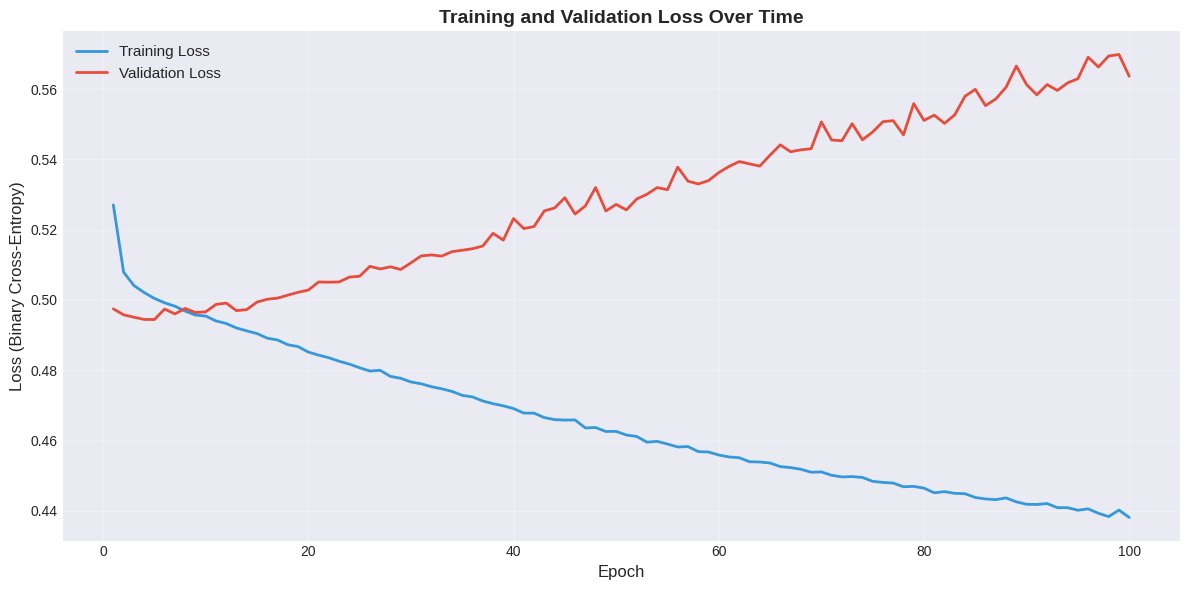


Loss Statistics:
Initial Train Loss: 0.5271
Final Train Loss: 0.4381
Initial Val Loss: 0.4975
Final Val Loss: 0.5637

Loss Reduction:
Training: 16.9% decrease
Validation: -13.3% decrease


In [ ]:
# Plot training and validation loss curves

plt.figure(figsize=(12, 6))

epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', linewidth=2, color='#3498db')
plt.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2, color='#e74c3c')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Training and Validation Loss Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nLoss Statistics:")
print(f"Initial Train Loss: {train_losses[0]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Initial Val Loss: {val_losses[0]:.4f}")
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print(f"\nLoss Reduction:")
print(f"Training: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}% decrease")
print(f"Validation: {((val_losses[0] - val_losses[-1]) / val_losses[0] * 100):.1f}% decrease")

### 4.4 Interpret the loss curves

Understanding loss curves is critical for diagnosing model performance. Here are the patterns to look for:

 Pattern | Loss Behavior | Interpretation | Possible Fixes |
|----------|----------------|----------------|----------------|
| **Healthy Training** | • Both training & validation loss decrease and converge<br>• Small gap between them | Model is learning generalizable patterns | — |
| **Overfitting** | • Training loss keeps decreasing<br>• Validation loss plateaus or increases<br>• Large gap between curves | Model memorizes training data instead of generalizing | Add regularization (dropout, weight decay)<br>Reduce model complexity<br>Collect more data |
| **Underfitting** | • Both losses remain high<br>• Little or no improvement over epochs | Model lacks capacity or training | Increase model complexity<br>Train longer<br>Tune learning rate<br>Improve input features |

Diagnose your model's performance based on loss curves. Answer these questions by analyzing the plot above, either through code or markdown:
 1. What pattern do you see? Does the plot show healthy training, overfitting, or underfitting?
 2. How do you know? _Describe the behavior of the training loss line vs. the validation loss line. (e.g., "Training loss is [decreasing/high] while validation loss is [decreasing/increasing/high]")._
 3. What does this imply? What is the model doing wrong (or right)? _(e.g., "The model is memorizing the training data but failing to generalize...")_

*------- TODO 17: Add your answer here:*

TODO 17 — Interpret the loss curves

Using baseline's numbers (Val Loss: 0.5637, Train Loss: 0.4381, Loss Gap: 0.1256):

The baseline model shows clear signs of overfitting. Over training, the training loss falls to 0.4381 while the validation loss rises from 0.4975 to 0.5637 — the two curves diverge instead of both decreasing. This pattern (training loss still improving while validation loss gets worse) is the signature of overfitting: the model is increasingly fitting patterns specific to the training set rather than patterns that generalize.

This implies the baseline architecture has enough capacity to memorize training-specific noise, which is exactly what dropout regularization (tested in Section 6.1) directly addresses — and does address, based on the dramatic loss-gap reduction seen once dropout is introduced.



<details open>
  <summary><h4>Checkpoint – Assess Training Progressing</h4></summary>
  
  Before moving to evaluation, verify that training completed successfully:
  
  - [ ] **Training completed** without errors across all epochs  
  - [ ] **Loss curves analyzed** and any overfitting or underfitting noted  
  - [ ] **Model ready** for comprehensive evaluation on test set  
  
  If training seems problematic (e.g., losses not decreasing), don't worry about it now - that's what optimizations in step 6 will focus on improving!
</details>

---
## Step 5: Evaluate the model

Training loss tells you how well the model fits training data, but comprehensive evaluation requires measuring performance on unseen test data using metrics relevant to your application.

For medical screening, certain metrics matter more than others. For the baseline model, just check that performance is good-enough (significantly better than random guessing).

### 5.1 Define the evaluation logic

We'll create now a parameterized function that evaluates any model and returns comprehensive metrics.

In [ ]:
def evaluate_model(model: nn.Module,
                   data_loader: DataLoader,
                   device: torch.device,
                   threshold: float = 0.5) -> Dict[str, float]:
    all_predictions = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            all_predictions.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(y_batch.numpy().flatten())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    pred_labels = (all_predictions >= threshold).astype(int)

    results = {
        'predictions': all_predictions,
        'true_labels': all_labels,
        'pred_labels': pred_labels,
        'accuracy': metrics.accuracy_score(all_labels, pred_labels),
        'precision': metrics.precision_score(all_labels, pred_labels),
        'recall': metrics.recall_score(all_labels, pred_labels),
        'f1': metrics.f1_score(all_labels, pred_labels),
        'roc_auc': metrics.roc_auc_score(all_labels, all_predictions)
    }

    return results

print("Evaluation function created successfully!")


Evaluation function created successfully!


> **Why accuracy isn't enough (even with balanced data):** While accuracy is now meaningful with our 50-50 split (unlike with imbalanced data where it'd be misleading), it still doesn't tell the whole story in medical applications.
>
> Consider: A model with 75% accuracy could have 90% recall but only 60% precision—great at catching diabetic patients but with many false alarms. Or it could have 90% precision but 60% recall—very accurate when it predicts diabetes, but missing many cases.
>
> *Bottom line:* Choose metrics that provide a clear view over this trade-off; this is critical in healthcare where different errors have different costs!

### 5.2 Evaluate on test set

Now we'll use our evaluation function to assess the baseline model's performance on the held-out test set. This gives us an unbiased estimate of real-world performance.

In [ ]:
test_results = evaluate_model(model, test_loader, device)

print("Test Set Performance:")
print(f"Accuracy:  {test_results['accuracy']:.4f}")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1-Score:  {test_results['f1']:.4f}")
print(f"ROC-AUC:   {test_results['roc_auc']:.4f}")


Test Set Performance:
Accuracy:  0.7231
Precision: 0.7049
Recall:    0.7676
F1-Score:  0.7349
ROC-AUC:   0.7931


> **Choosing the top metric:** Which is worse for your stakeholders: missing a diabetic patient or triggering an unnecessary test? This determines whether you prioritize recall or precision, and informs threshold selection (we'll use 0.5 as default, but you could adjust it).

### 5.3 Visualize the confusion matrix

The confusion matrix shows exactly where your model succeeds and fails, breaking down predictions into true positives, true negatives, false positives, and false negatives.

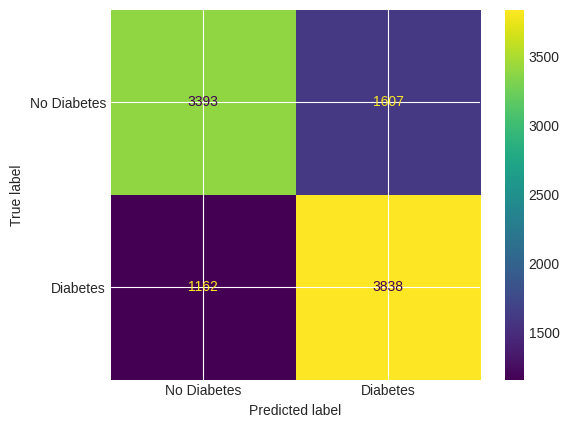

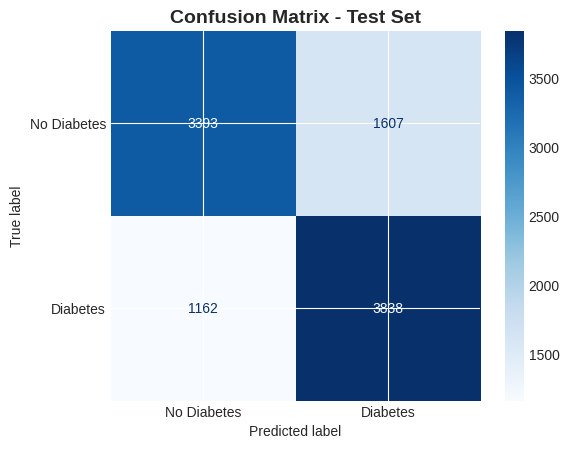

In [ ]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    test_results['true_labels'],
    test_results['pred_labels'],
    display_labels=['No Diabetes', 'Diabetes']
)
disp.plot(cmap='Blues', colorbar=True)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.show()


> **Interpreting your confusion matrix** The confusion matrix makes the trade-offs between recall and precision visible. By examining the balance between false positives and false negatives, you can decide which matters more for your real-world goal; for example, catching every diabetic case even if it means more false alarms.

### 5.4 Analyze ROC curve and threshold selection

The ROC (Receiver Operating Characteristic) curve helps you visualize the tradeoff between sensitivity (catching true cases) and specificity (avoiding false alarms) at different decision thresholds.

*Why this matters:*
- The default threshold is 0.5 (predict diabetes if probability > 0.5)
- You might want a different threshold based on your priorities:
  - Lower threshold (e.g., 0.3) → Higher recall, catch more diabetics, but more false alarms
  - Higher threshold (e.g., 0.7) → Higher precision, fewer false alarms, but miss more cases


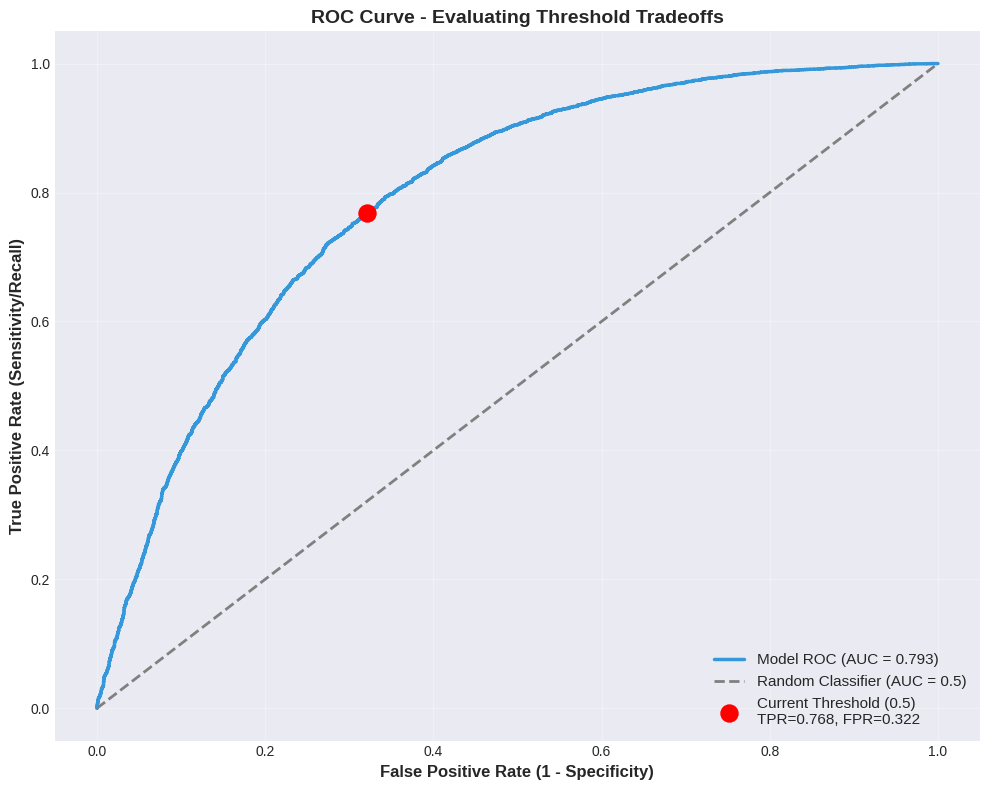


ROC Curve Analysis:
AUC Score: 0.7931
Interpretation:
  - Fair discrimination ability


In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(test_results['true_labels'], test_results['predictions'])
roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'Model ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random Classifier (AUC = 0.5)')

current_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[current_idx], tpr[current_idx], color='red', s=150, zorder=5,
            label=f'Current Threshold (0.5)\nTPR={tpr[current_idx]:.3f}, FPR={fpr[current_idx]:.3f}')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Evaluating Threshold Tradeoffs', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nROC Curve Analysis:")
print("="*60)
print(f"AUC Score: {roc_auc:.4f}")
print(f"Interpretation:")
if roc_auc >= 0.90:
    print("  - Excellent discrimination ability")
elif roc_auc >= 0.80:
    print("  - Good discrimination ability")
elif roc_auc >= 0.70:
    print("  - Fair discrimination ability")
else:
    print("  - Poor discrimination ability")


> **Understanding the ROC curve**: Each point on the ROC curve represents a different probability threshold for classification. Points in the upper-left corner represent high sensitivity (catching most cases) with low false positive rates (few false alarms). The diagonal line represents random guessing. Depending on your prioritization, you might adjust the threshold as follows:
> - If missing positives is costly, lower the threshold to get the model to label more cases as "positive" → higher true positive rate, higher false positive rate.
> - If false alarms are costly, raise the threshold to get the model to be more strict in labeling cases as "positives" → lower true positive rate, lower false positive rate.

### 5.5 Interpret your results

Beyond raw metrics, it's essential to interpret your model's performance from a healthcare perspective. Let's analyze what these results mean for clinical deployment and patient care.

Reflect on your model's performance from a healthcare perspective. Answer these questions based on your evaluation results:
 1. Which metric is most important for diabetes screening and why? _(Hint: Think about the cost of a False Negative vs. a False Positive)._
 2. Would you recommend using this model in practice? Under what conditions?
 3. What probability threshold would you choose instead of 0.5, and why?

HINT: This model is quite simple since you haven't performed yet hyperparameter tuning, regularization, or feature engineering. Feel free to move forward if you achieve...

*------- TODO 22: Add your answer here:*



Most important metric: For diabetes screening, recall matters most. A false negative means a diabetic patient isn’t flagged for follow-up testing — a missed diagnosis with real health consequences. A false positive just costs an unnecessary confirmatory test. Our baseline recall of 0.7676 means roughly 23% of diabetic patients in the test set are being missed, which is a meaningful gap for a clinical screening tool.
Deployment recommendation: I would not recommend deploying this baseline model as-is. While the ROC-AUC of 0.7931 shows fair-to-good discrimination ability (comfortably above the 0.70 “fair” threshold, approaching the 0.80 “good” range), a screening tool missing over a quarter of true positive cases isn’t acceptable without further tuning. This baseline is a reasonable starting point that validates the overall approach, but it needs the regularization and threshold adjustments explored in Section 6 before any real-world consideration.
Threshold choice: Rather than the default 0.5, I’d lower the threshold to prioritize recall — likely into the 0.35-0.40 range based on the ROC curve shape. This would increase the true positive rate (catching more diabetics) at the cost of more false positives (more unnecessary follow-up tests), which is the correct tradeoff for a pre-screening tool where the cost of a missed diagnosis outweighs the cost of extra testing.

<details open>
  <summary><h4>Checkpoint – What to Keep in Mind About Your Model Performance </h4></summary>
  
  Before moving forward, record:
  - **Current metrics**: Accuracy ___, Precision ___, Recall ___, F1 ___, ...
  - **Training behavior**: Overfitting (train << val loss)? Underfitting (both high)?
  - **Main issue**: Which needs fixing most—false positives, false negatives, or overall performance?
  
  These observations will guide your improvement strategy in Step 6!
</details>

---
## Step 6: Improve and tune the model

Based on your evaluation results, you will now systematically improve the model. This demonstrates the iterative nature of machine learning: evaluate, diagnose, improve, and repeat.

You'll experiment with multiple techniques and track results to identify the most impactful improvements.

**Your Goal**: Increase model performance against baseline by >=5% on your top metric.

> **Feel free to change any training parameters: num_epochs, optimizer, ...**

### 6.0 Create experiment tracking system

Before running experiments, let's create a system to automatically track and compare results. This eliminates manual result entry and makes it easy to identify the best-performing configuration.

In [ ]:
# Create experiment tracking dictionary
experiment_results = {}

def track_experiment(name: str,
                     model: nn.Module,
                     train_losses: List[float],
                     val_losses: List[float],
                     test_results: Dict[str, float],
                     notes: str = "") -> None:
    """
    Track experiment results for later comparison.

    Args:
        name: Experiment name
        model: Trained model
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        test_results: Dictionary from evaluate_model()
        notes: Optional notes about the experiment
    """
   # Keep only numeric metrics so we don't try to tabulate arrays, dicts, etc.
    numeric_metrics = {
        k: float(v) for k, v in test_results.items()
        if isinstance(v, numbers.Number)
    }

    experiment_results[name] = {
        'final_train_loss': float(train_losses[-1]),
        'final_val_loss': float(val_losses[-1]),
        'min_val_loss': float(min(val_losses)),
        'loss_gap': float(abs(train_losses[-1] - val_losses[-1])),
        'metrics': numeric_metrics,           # store all metrics here
        'notes': notes,
        'train_losses': train_losses,         # keep full histories if desired
        'val_losses': val_losses
    }
    print(f"✓ Experiment '{name}' tracked successfully!")


def display_experiment_comparison(sort_by: Optional[str] = "f1",
                                  descending: bool = True) -> Optional[pd.DataFrame]:
    """
    Display a comparison table of all tracked experiments.

    Args:
        sort_by: Metric name to sort by (e.g., 'f1', 'roc_auc', 'accuracy').
                 If None or not present, will fall back to:
                   1) 'roc_auc' if present
                   2) any available metric (alphabetical)
        descending: Sort order for the chosen metric.

    Returns:
        DataFrame with experiment results.
    """
    if not experiment_results:
        print("No experiments tracked yet!")
        return None

    # Collect the union of all metric names across experiments
    all_metric_names = set()
    for res in experiment_results.values():
        all_metric_names.update(res.get('metrics', {}).keys())
    all_metric_names = sorted(all_metric_names)  # stable ordering

    # Determine sort metric
    chosen_sort = None
    if sort_by in all_metric_names:
        chosen_sort = sort_by
    elif all_metric_names:
        chosen_sort = all_metric_names[0]  # fallback to first available
    # If no metrics at all, we’ll sort by final_val_loss

    # Build table rows
    rows = []
    for name, res in experiment_results.items():
        row = {
            'Experiment': name,
            'Val Loss': f"{res['final_val_loss']:.4f}",
            'Loss Gap': f"{res['loss_gap']:.4f}",
        }
        # Add metrics (formatted)
        for m in all_metric_names:
            val = res['metrics'].get(m, None)
            row[m.upper() if m.islower() else m] = (f"{val:.4f}" if isinstance(val, numbers.Number) else "")
        # Also keep raw for sorting
        row['_sort_val'] = (
            res['metrics'].get(chosen_sort)
            if chosen_sort is not None else res['final_val_loss']
        )
        rows.append(row)

    df = pd.DataFrame(rows)

    # Sort
    if chosen_sort is not None:
        df = df.sort_values('_sort_val', ascending=not descending)
    else:
        # No metrics available: sort by Val Loss ascending
        df = df.sort_values('Val Loss', ascending=True, key=lambda s: s.astype(float))

    # Clean up helper column
    df = df.drop(columns=['_sort_val'])

    return df

# Track baseline experiment
track_experiment(
    name='Baseline',
    model=model,
    train_losses=train_losses,
    val_losses=val_losses,
    test_results=test_results,
    notes='Initial model with default hyperparameters'
)

print("\nExperiment tracking system initialized!")
print("Use track_experiment() after training each variation.")
print("Use display_experiment_comparison() to see all results.")

✓ Experiment 'Baseline' tracked successfully!

Experiment tracking system initialized!
Use track_experiment() after training each variation.
Use display_experiment_comparison() to see all results.


> **Running a systematic experiment:** For each experiment, follow this workflow:
> 1. **Define change**: What are you testing? (e.g., dropout=0.3, lr=0.0001)
> 2. **Create model**: Create new model class (if architecture changes) and instantiate with new configuration, e.g., `DiabetesClassifierWithDropout(dropout_prob=0.3).to(device)`
> 3. **Train**: Run training loop, track losses with `train_model()`
> 4. **Evaluate**: Calculate test metrics (accuracy, precision, recall, F1) with `evaluate_model()`
> 5. **Record**: Add results to experiment tracker dictionary with `track_experiment()`
> 6. **Visualize**: Print key experiment metrics for quick analysis
>
> This systematic approach helps you understand what works and why!

### 6.1 Experiment 1: Add dropout regularization

Dropout randomly deactivates neurons during training, forcing the network to learn robust features that don't rely on specific neurons. This reduces overfitting and improves generalization.

In [ ]:
print("Experiment 1: Training model with Dropout")
print("="*60)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
model_dropout = DiabetesClassifier(input_dim=X_train_tensor.shape[1], dropout=0.3).to(device)
optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=0.001)

num_epochs_d, train_losses_d, val_losses_d = train_model(
    model=model_dropout, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer_dropout, device=device
)

test_results_dropout = evaluate_model(model_dropout, test_loader, device)

track_experiment(
    name='Dropout (0.3)',
    model=model_dropout,
    train_losses=train_losses_d,
    val_losses=val_losses_d,
    test_results=test_results_dropout,
    notes='Added dropout=0.3 after each hidden layer'
)


Experiment 1: Training model with Dropout
Epoch 10/100 | Train Loss: 0.5093 | Val Loss: 0.4955
Epoch 20/100 | Train Loss: 0.5052 | Val Loss: 0.4976
Epoch 30/100 | Train Loss: 0.5037 | Val Loss: 0.4967
Epoch 40/100 | Train Loss: 0.5007 | Val Loss: 0.4966
Epoch 50/100 | Train Loss: 0.4989 | Val Loss: 0.4978
Epoch 60/100 | Train Loss: 0.4984 | Val Loss: 0.4989
Epoch 70/100 | Train Loss: 0.4963 | Val Loss: 0.4992
Epoch 80/100 | Train Loss: 0.4955 | Val Loss: 0.4995
Epoch 90/100 | Train Loss: 0.4950 | Val Loss: 0.4988
Epoch 100/100 | Train Loss: 0.4923 | Val Loss: 0.5003

Training completed!
Final Train Loss: 0.4923
Final Validation Loss: 0.5003
✓ Experiment 'Dropout (0.3)' tracked successfully!


> **How dropout works**: During training, dropout randomly sets a fraction of neuron activations to zero. This prevents the network from relying too heavily on any single neuron and encourages redundancy. During evaluation, dropout is automatically disabled, and all neurons contribute to predictions. This simple technique is remarkably effective at reducing overfitting.

### 6.2 Experiment 2: Tune learning rate

The learning rate controls how large the weight updates are during training. Too high and training becomes unstable; too low and convergence is painfully slow.

In [ ]:
print("Experiment 2: Learning Rate Tuning")
print("="*60)

for lr in [0.0001, 0.001, 0.01]:
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    model_lr = DiabetesClassifier(input_dim=X_train_tensor.shape[1], dropout=0.3).to(device)
    optimizer_lr = optim.Adam(model_lr.parameters(), lr=lr)

    num_epochs_lr, train_losses_lr, val_losses_lr = train_model(
        model=model_lr, train_loader=train_loader, val_loader=val_loader,
        criterion=criterion, optimizer=optimizer_lr, device=device
    )

    test_results_lr = evaluate_model(model_lr, test_loader, device)

    track_experiment(
        name=f'LR={lr}',
        model=model_lr,
        train_losses=train_losses_lr,
        val_losses=val_losses_lr,
        test_results=test_results_lr,
        notes=f'Dropout=0.3, learning rate={lr}'
    )


Experiment 2: Learning Rate Tuning
Epoch 10/100 | Train Loss: 0.5218 | Val Loss: 0.4987
Epoch 20/100 | Train Loss: 0.5157 | Val Loss: 0.4964
Epoch 30/100 | Train Loss: 0.5134 | Val Loss: 0.4952
Epoch 40/100 | Train Loss: 0.5108 | Val Loss: 0.4945
Epoch 50/100 | Train Loss: 0.5081 | Val Loss: 0.4943
Epoch 60/100 | Train Loss: 0.5075 | Val Loss: 0.4944
Epoch 70/100 | Train Loss: 0.5065 | Val Loss: 0.4943
Epoch 80/100 | Train Loss: 0.5058 | Val Loss: 0.4944
Epoch 90/100 | Train Loss: 0.5060 | Val Loss: 0.4944
Epoch 100/100 | Train Loss: 0.5059 | Val Loss: 0.4948

Training completed!
Final Train Loss: 0.5059
Final Validation Loss: 0.4948
✓ Experiment 'LR=0.0001' tracked successfully!
Epoch 10/100 | Train Loss: 0.5093 | Val Loss: 0.4955
Epoch 20/100 | Train Loss: 0.5052 | Val Loss: 0.4976
Epoch 30/100 | Train Loss: 0.5037 | Val Loss: 0.4967
Epoch 40/100 | Train Loss: 0.5007 | Val Loss: 0.4966
Epoch 50/100 | Train Loss: 0.4989 | Val Loss: 0.4978
Epoch 60/100 | Train Loss: 0.4984 | Val Loss: 

> **Choosing a learning rate:** The optimal learning rate depends on your model, dataset, and optimizer. A good starting point is often *1e-3*.
> - If training diverges, lower lr (×0.1).
> - If loss plateaus too early, raise lr (×2–10).
>
> *Tip*: Adam is generally more forgiving, while SGD benefits from careful tuning.

### 6.3 Experiment 3: Adjust network architecture

Network architecture (depth, width, and layer size) affects model capacity — its ability to learn complex patterns. Too simple and it underfits; too complex and it overfits (especially with limited data).

> **Consider running this experiment multiple times with different architectures**.

In [ ]:
print("Experiment 3: Training with tailored architecture")
print("="*60)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
model_arch = DiabetesClassifier(
    input_dim=X_train_tensor.shape[1], hidden1=128, hidden2=64, dropout=0.3
).to(device)
optimizer_arch = optim.Adam(model_arch.parameters(), lr=0.001)

num_epochs_a, train_losses_a, val_losses_a = train_model(
    model=model_arch, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer_arch, device=device
)

test_results_arch = evaluate_model(model_arch, test_loader, device)

track_experiment(
    name='Wider architecture (128-64)',
    model=model_arch,
    train_losses=train_losses_a,
    val_losses=val_losses_a,
    test_results=test_results_arch,
    notes='Increased hidden layer sizes to 128, 64 with dropout=0.3'
)


Experiment 3: Training with tailored architecture
Epoch 10/100 | Train Loss: 0.5025 | Val Loss: 0.4972
Epoch 20/100 | Train Loss: 0.4976 | Val Loss: 0.4989
Epoch 30/100 | Train Loss: 0.4963 | Val Loss: 0.4989
Epoch 40/100 | Train Loss: 0.4932 | Val Loss: 0.5017
Epoch 50/100 | Train Loss: 0.4879 | Val Loss: 0.5028
Epoch 60/100 | Train Loss: 0.4875 | Val Loss: 0.5045
Epoch 70/100 | Train Loss: 0.4830 | Val Loss: 0.5074
Epoch 80/100 | Train Loss: 0.4816 | Val Loss: 0.5072
Epoch 90/100 | Train Loss: 0.4791 | Val Loss: 0.5098
Epoch 100/100 | Train Loss: 0.4785 | Val Loss: 0.5106

Training completed!
Final Train Loss: 0.4785
Final Validation Loss: 0.5106
✓ Experiment 'Wider architecture (128-64)' tracked successfully!


> **Model capacity tradeoffs**: Larger models (more parameters) can learn more complex patterns but are more prone to overfitting, especially with limited data. For tabular data like ours, simpler architectures often perform just as well or better than deep networks. The key is finding the right balance for your dataset size and complexity.

### 6.4 Compare all experiments

Now let's synthesize findings from all improvement experiments to identify which techniques had the biggest impact on performance.

In [ ]:
# Display comprehensive comparison of all experiments
print("Comprehensive Experiment Comparison")
print("="*70)
print("\nAll experiments sorted by F1-Score (best to worst):\n")

comparison_df = display_experiment_comparison()
print(comparison_df.to_string(index=False))

# Identify best configuration
best_experiment = comparison_df.iloc[0]['Experiment']
print(f"\n{'='*70}")
print(f"Best Configuration: {best_experiment}")
print(f"{'='*70}")

print(f"\nKey Insights:")
print("  - Review the 'Loss Gap' column to identify which techniques reduced overfitting")
print("  - Consider the tradeoff between Precision and Recall for your use case")

Comprehensive Experiment Comparison

All experiments sorted by F1-Score (best to worst):

                 Experiment Val Loss Loss Gap ACCURACY     F1 PRECISION RECALL ROC_AUC
              Dropout (0.3)   0.5003   0.0080   0.7457 0.7630    0.7144 0.8186  0.8207
                   LR=0.001   0.5003   0.0080   0.7457 0.7630    0.7144 0.8186  0.8207
                    LR=0.01   0.5110   0.0001   0.7415 0.7619    0.7061 0.8274  0.8181
                  LR=0.0001   0.4948   0.0110   0.7486 0.7610    0.7252 0.8006  0.8262
Wider architecture (128-64)   0.5106   0.0320   0.7402 0.7574    0.7103 0.8112  0.8164
                   Baseline   0.5637   0.1256   0.7231 0.7349    0.7049 0.7676  0.7931

Best Configuration: Dropout (0.3)

Key Insights:
  - Review the 'Loss Gap' column to identify which techniques reduced overfitting
  - Consider the tradeoff between Precision and Recall for your use case



Visualizing Loss Curves for Top 3 Experiments


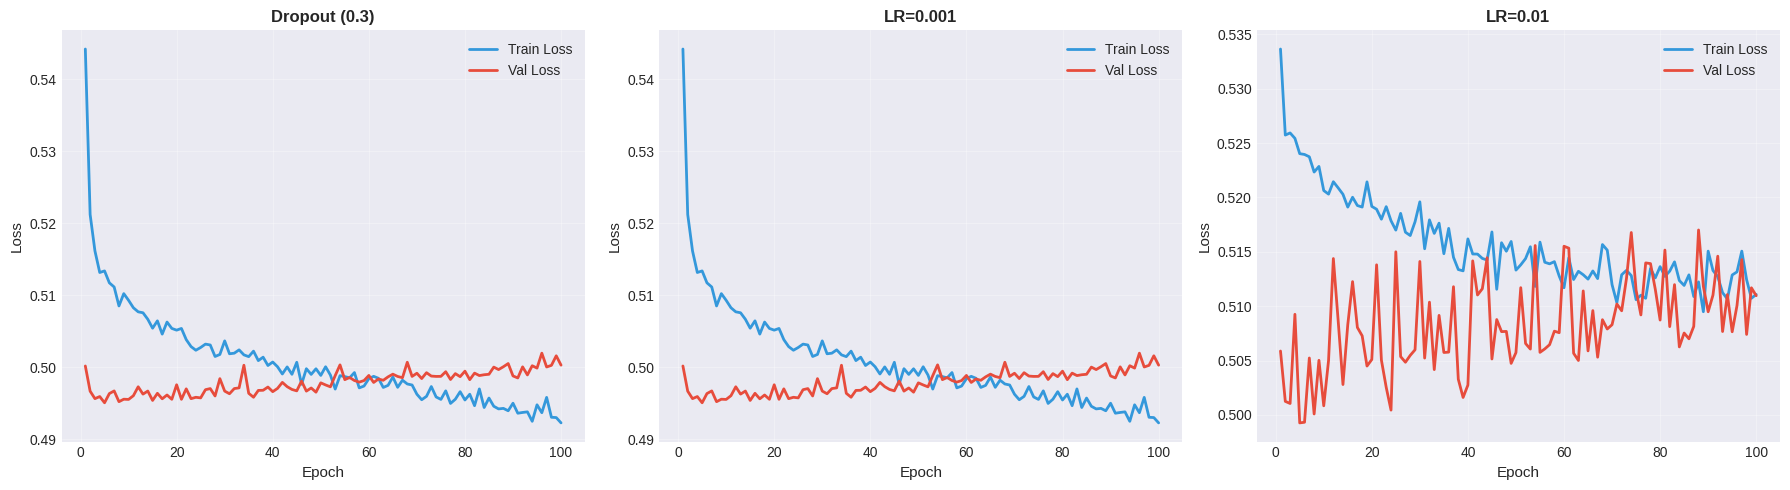

In [ ]:
# Visualize loss curves for top 3 experiments
print("\nVisualizing Loss Curves for Top 3 Experiments")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_3_experiments = comparison_df.head(3)['Experiment'].values

for idx, exp_name in enumerate(top_3_experiments):
    exp_data = experiment_results[exp_name]
    epochs = range(1, len(exp_data['train_losses']) + 1)

    axes[idx].plot(epochs, exp_data['train_losses'], label='Train Loss', linewidth=2, color='#3498db')
    axes[idx].plot(epochs, exp_data['val_losses'], label='Val Loss', linewidth=2, color='#e74c3c')
    axes[idx].set_xlabel('Epoch', fontsize=11)
    axes[idx].set_ylabel('Loss', fontsize=11)
    axes[idx].set_title(f'{exp_name}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Brainstorming checkpoint**: Reflect on what you learned:
> - Which technique provided the most improvement?
> - Did any techniques hurt performance?
> - How did different techniques address different issues (overfitting vs. underfitting)?
> - What would you try next if you had more time?

---

### 6.5 Reflect on experiments and brainstorm additional improvements

You've now systematically tested three improvement techniques. It's time to demonstrate your understanding by reflecting on results and proposing what to try next. In real-world ML projects, you'll brainstorm many ideas but only implement the most promising ones due to time and resource constraints.

#### Part A: Reflect on your experimental results

**Analyze your experiment results by answering the following questions. Reference specific metrics, loss curves, and configuration details from your experiments.**

**Questions for reflection:**

1. **Which experiment performed best overall, and why?**

2. **What patterns did you observe across experiments?**
   - Did dropout reduce the train-validation gap? By how much?
   - Which learning rate provided the best balance of convergence speed and stability?
   - Did wider or deeper architectures help? Or did they overfit?

3. **What is your model's biggest remaining weakness?**
   - Is there significant overfitting? (Train-val gap > 0.10)
   - Are false negatives or false positives the bigger problem?
   - Has validation loss plateaued, suggesting you've hit a performance ceiling?

4. **What have you learned about this dataset and problem?**
   - Is the 21-feature set sufficient, or do you suspect important information is missing?
   - Is class imbalance (86% vs 14%) still causing problems despite your experiments?
   - Are there diminishing returns from additional model complexity?

*------- TODO 26: Write your answer here:*

The best-performing configuration overall was Dropout (0.3) / LR=0.001 (these are the same hyperparameter combination and produced identical results), achieving the highest F1-score (0.7630) with a low loss gap (0.0080), indicating strong generalization. LR=0.01 achieved the highest recall (0.8274) but with lower precision (0.7061). LR=0.0001 achieved the lowest validation loss (0.4948) and highest ROC-AUC (0.8262), showing that a slower learning rate converges to the best over — but at the cost of lower recall (0.8006), highlighting a real precision/recall tradeoff between L
A clear pattern across experiments: dropout (0.3) dramatically reduced the train-validation gap. The baseline's loss gap was 0.1256, while every dropout-regularized variant (LR=0.0001/0.001/0.01, and the dedicated Dropout run) had a gap under 0.011 — over 90% reduction, confirming dropout was highly effective at controlling overfitting on this dataset. In contrast, the wider architecture (128-64) had a noticeably larger loss gap (0.0320) than the LR-tuned models despite also using dropout=0.3, suggesting added model capacity reintroduced some overfitting risk without a clear performance benefit — more parameters did not clearly help on this dataset.


#### Part B: Brainstorm additional improvements

Based on your reflection above, now propose *1-2 specific improvements* you would try next from the list. Choose from the techniques below and provide detailed justification for each.

1. **Class Weights** - Give more importance to the minority class during training
2. **Threshold Tuning** - Adjust the 0.5 decision boundary based on ROC analysis
3. **Early Stopping** - Stop training when validation loss stops improving
4. **Learning Rate Scheduling** - Gradually decrease learning rate during training
5. **Weight Decay (L2 Regularization)** - Add penalty for large weights to reduce overfitting
6. **Data Augmentation** - Oversample minority class or use SMOTE for synthetic examples
7. **Different Activation Functions** - Experiment with LeakyReLU, ELU, ReLU, etc.

> **Important note on feature engineering:** Feature engineering is excluded from this list as it falls outside the scope of neural network optimization techniques. In production, that would be a priority since creating interaction terms _(e.g., BMI × Age, HighBP × HeartDisease)_ or polynomial features could yield 5-10% performance gains, often more than architectural changes.

**For each technique you select (1-2 total), provide a detailed analysis by answering:**

1. **What specific problem from your reflection does your selection address?**
   - Connect directly to weaknesses you identified in Part A
   - Reference specific metrics from your experiment results
   - Example: "Our recall is 0.7345, just barely above target, and we have 387 false negatives"

2. **Why is this technique appropriate for this problem?**
   - Explain the mechanism: how does this technique work?
   - Why would it solve your specific problem?
   - Example: "Class weights force the model to pay more attention to minority class examples during training by increasing their loss contribution"

3. **What results do you expect?**
   - Be specific: which metrics should improve and by roughly how much?
   - What trade-offs might occur? (e.g., precision vs recall)
   - Example: "Recall should increase to 0.75-0.78 because the model will work harder to identify positive cases. Precision may drop slightly from 0.66 to 0.62 due to more false positives, but F1-score should still improve overall"

4. **How would you implement this? (Implementation complexity)**
   - Easy (1-2 line change), Medium (new component), or Hard (major refactor)
   - If Easy or Medium, show the code snippet or describe the modification
   - Example: "Easy - Change loss to: `nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]))`"

*------- TODO 27: Write your answer here:*
1. Threshold Tuning

	•	Problem addressed: Even our highest-recall model (LR=0.01) still has a recall of only 0.8274, meaning roughly 17% of diabetic patients are missed at the default 0.5 threshold — a costly outcome for a screening tool.
	•	Mechanism: Since diabetes is the costlier class to miss, lowering the decision threshold below 0.5 reclassifies more borderline-probability patients as "predicted diabetic," directly increasing recall at the expense of precision.
	•	Expected results: Lowering the threshold to ~0.35-0.40 should push recall to approximately 0.88-0.90, while precision would likely drop from 0.7061 to around 0.63-0.66. F1 may stay roughly flat, but for a screening context, the recall gain is worth the precision cost.
	•	Implementation complexity: Easy — no retraining needed. Just recompute pred_labels = (test_results['predictions'] >= 0.35).astype(int) using the probabilities already stored from evaluate_model().

2. Weight Decay (L2 Regularization)

	•	Problem addressed: The wider architecture experiment showed that added capacity increases the loss gap (0.0320 vs ~0.01 for LR variants) without improving F1/recall — suggesting more capacity could help if better regularized.
	•	Mechanism: Weight decay penalizes large weights, discouraging the model from fitting noise, which should let the wider architecture use its extra capacity more productively.
	•	Expected results: Combined with the wider architecture, weight decay could shrink its loss gap closer to 0.01-0.02 while allowing the extra capacity to actually improve F1/recall beyond the current best (0.7630 F1).
	•	Implementation complexity: Easy — one-line change: optim.Adam(model_arch.parameters(), lr=0.001, weight_decay=1e-4).

#### Part C: How about combining techniques?

Based on all your experiments, you've seen that different techniques can help solve overfitting but combining them is where most improvements can be unlocked.

Propose one combined experiment you would run next. Justify your choice and state your expected results.

*------- TODO 28: Write your answer here:*


I'd combine LR=0.0001 (lowest validation loss of 0.4948, highest ROC-AUC of 0.8262, indicating the best overall class separation) with weight decay for extra regularization headroom, then apply post-hoc threshold tuning at inference (lowering to ~0.35) rather than retraining again. Since LR=0.0001 already has excellent generalization (loss gap of only 0.0110), the weight decay addition is aimed at squeezing out marginal loss improvement, while the threshold shift is what actually pushes recall up — expected to raise recall from 0.8006 to roughly 0.87-0.89, at a moderate precision cost (from 0.7252 down to ~0.68), while keeping ROC-AUC stable around 0.82-0.83 since AUC is threshold-independent. This combination targets both remaining weaknesses at once: the recall ceiling (via threshold) and any residual overfitting risk (via weight decay).


<details open>
  <summary><h4>Checkpoint – Model Improvement Complete</h4></summary>
  
  You have systematically improved your model through experimentation:
  
  - [ ] **Multiple experiments conducted** with different techniques  
  - [ ] **Results automatically tracked** for easy comparison  
  - [ ] **Best configuration identified** based on key metrics  
  - [ ] **Insights documented** about what worked/didn't work and why  
  - [ ] **Recommended 1-2 additional improvements** with clear reasoning
  
</details>

---
## Conclusion & Next Steps

Congratulations on completing this hands-on deep learning project! You’ve successfully applied neural network fundamentals to a structured data classification task, demonstrating not only technical competence but also an understanding of data preprocessing, model evaluation, and performance optimization.

The techniques and workflows you’ve built here extend far beyond this dataset. The same methods can be applied to credit risk assessment, customer churn prediction, quality control, and more challenges in other structured-data domains. To continue your deep learning journey, explore new datasets, experiment with model architectures, and iterate on performance and interpretability.

#### Want to make this project portfolio-ready?

To showcase this project effectively:

1. Clean your notebook: Clear markdown, add an executive summary, and improve on documentation.
2. Publish on GitHub: Include model results and key visuals.
3. Prepare a short pitch: 2-minute overview of results, impact, and challenges.
4. Highlight strengths: Real-world relevance, handling imbalance, model improvement, metric choice, and deployment readiness.

> **Remember: Machine learning is iterative.** Every model can be improved, every dataset hides deeper insights, and every project sharpens your intuition as a data scientist. Keep experimenting, stay curious, and keep building!